**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
M.C. Joan Manuel Raygoza Romero

## ICD - 6: Limpieza de datos

Sesión 6 del curso. Diapositivas: [icd-06-aumento.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-06-aumento.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-06-aumento.ipynb)

Este notebook acompaña la presentación **Aumento de datos**. El objetivo es aplicar, de manera breve, técnicas representativas para:

- datos tabulares;
- series de tiempo;
- imágenes;
- texto;
- balanceo de clases y prevención de *data leakage*.

> Regla central: primero se separan entrenamiento y prueba; el aumento se aplica **solo al entrenamiento**.

## 1. Preparación

Se usan conjuntos incluidos en `scikit-learn` y ejemplos generados localmente, por lo que **no es necesario descargar datos externos**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_sample_image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.utils import resample
from PIL import Image, ImageEnhance, ImageFilter

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Diccionario de datos

El notebook utiliza un conjunto tabular incluido en `scikit-learn` y tres ejemplos didácticos: una serie temporal sintética, una imagen de muestra y una oración. No se combinan entre sí; cada uno ilustra técnicas de aumento apropiadas para su modalidad.

| Conjunto | Origen | Unidad de observación | Tamaño usado | Finalidad |
|---|---|---|---:|---|
| Breast Cancer Wisconsin (Diagnostic) | `sklearn.datasets.load_breast_cancer` | Núcleo celular obtenido de una imagen digitalizada | Se crea un subconjunto desbalanceado de 412 casos | Aumento tabular, oversampling y SMOTE |
| Serie temporal sintética | Generada en el notebook | Punto temporal de una señal | 240 puntos | Jittering, scaling, magnitude warping y window slicing |
| Imagen `china.jpg` | `sklearn.datasets.load_sample_image` | Píxel RGB | Redimensionada a 320 × 214 píxeles | Transformaciones geométricas y fotométricas, MixUp y CutMix |
| Texto sintético | Escrito en el notebook | Palabra/token | Una oración de 8 palabras | Easy Data Augmentation (EDA) |

### 2.1 Breast Cancer Wisconsin (Diagnostic)

Cada fila corresponde a un núcleo celular. Las variables se calculan a partir de imágenes digitalizadas de una aspiración con aguja fina de una masa mamaria. Hay diez características geométricas básicas y tres resúmenes de cada una: media, error estándar y valor “worst” (promedio de los tres valores más grandes). Las unidades físicas no se especifican en el conjunto distribuido por `scikit-learn`.

**Variable objetivo**

| Variable | Tipo | Valores | Significado |
|---|---|---|---|
| `target` | Categórica binaria | `0`, `1` | `0 = malignant` (maligno), `1 = benign` (benigno) |

In [2]:
# Diccionario de las 30 variables predictoras del conjunto tabular.
feature_meaning = {
    "radius": "Media de las distancias del centro a los puntos del perímetro",
    "texture": "Desviación estándar de los valores de intensidad en escala de grises",
    "perimeter": "Perímetro del núcleo celular",
    "area": "Área del núcleo celular",
    "smoothness": "Variación local de las longitudes del radio",
    "compactness": "Compacidad, calculada como perímetro²/área - 1",
    "concavity": "Severidad de las porciones cóncavas del contorno",
    "concave points": "Número de porciones cóncavas del contorno",
    "symmetry": "Simetría del núcleo celular",
    "fractal dimension": "Aproximación de la dimensión fractal del contorno"
}

def describe_feature(name):
    if name.startswith("mean "):
        statistic, base = "Media", name.removeprefix("mean ")
    elif name.endswith(" error"):
        statistic, base = "Error estándar", name.removesuffix(" error")
    elif name.startswith("worst "):
        statistic, base = "Worst: media de los 3 valores más grandes", name.removeprefix("worst ")
    else:
        statistic, base = "Resumen no identificado", name
    return feature_meaning[base], statistic

dictionary_source = load_breast_cancer()
rows = []
for feature in dictionary_source.feature_names:
    meaning, statistic = describe_feature(feature)
    rows.append({
        "Variable": feature,
        "Tipo": "Numérica continua",
        "Característica medida": meaning,
        "Resumen": statistic,
        "Unidad/escala": "No especificada"
    })

breast_cancer_dictionary = pd.DataFrame(rows)
breast_cancer_dictionary

,Variable,Tipo,Característica medida,Resumen,Unidad/escala
0,mean radius,Numérica continua,Media de las distancias del centro a los punto...,Media,No especificada
1,mean texture,Numérica continua,Desviación estándar de los valores de intensid...,Media,No especificada
2,mean perimeter,Numérica continua,Perímetro del núcleo celular,Media,No especificada
3,mean area,Numérica continua,Área del núcleo celular,Media,No especificada
4,mean smoothness,Numérica continua,Variación local de las longitudes del radio,Media,No especificada
5,mean compactness,Numérica continua,"Compacidad, calculada como perímetro²/área - 1",Media,No especificada
6,mean concavity,Numérica continua,Severidad de las porciones cóncavas del contorno,Media,No especificada
7,mean concave points,Numérica continua,Número de porciones cóncavas del contorno,Media,No especificada
8,mean symmetry,Numérica continua,Simetría del núcleo celular,Media,No especificada
9,mean fractal dimension,Numérica continua,Aproximación de la dimensión fractal del contorno,Media,No especificada


### 2.2 Serie temporal sintética

| Variable | Tipo | Descripción | Unidad/escala |
|---|---|---|---|
| `t` | Numérica continua | Coordenada temporal uniforme entre 0 y $4\pi$ | Unidad temporal arbitraria |
| `signal` | Numérica continua | $\sin(t)+0.25\sin(3t)$ | Amplitud arbitraria |
| `jitter` | Numérica continua | Señal original más ruido gaussiano $N(0,0.05^2)$ | Amplitud arbitraria |
| `scaling` | Numérica continua | Señal multiplicada por un factor aleatorio cercano a 1 | Amplitud arbitraria |
| `magnitude_warp` | Numérica continua | Señal multiplicada por una curva suave variable | Amplitud arbitraria |
| `window_slice` | Numérica continua | Recorte del 80 % de la señal, reinterpolado a 240 puntos | Amplitud arbitraria |

La serie no tiene etiqueta porque únicamente se muestran transformaciones. En una tarea supervisada, todas las versiones conservarían la etiqueta de la serie original solo si la transformación no cambia su clase.

### 2.3 Imagen de ejemplo

| Elemento | Tipo | Descripción | Valores |
|---|---|---|---|
| `img` | Imagen RGB | Fotografía `china.jpg` incluida en `scikit-learn` | Tres canales: rojo, verde y azul |
| Píxel | Entero por canal | Intensidad de color antes de normalizar | 0–255 |
| `img_small` | Imagen RGB | Imagen redimensionada para el ejercicio | 320 × 214 píxeles |
| `img_a`, `img_b` | Arreglos numéricos | Imágenes normalizadas para MixUp y CutMix | Valores reales entre 0 y 1 |

No se utiliza una etiqueta real. Las operaciones se presentan visualmente para mostrar cómo se construirían nuevas imágenes de entrenamiento.

### 2.4 Texto sintético

| Variable | Tipo | Descripción |
|---|---|---|
| `sentence` | Cadena de texto | Oración original: “el modelo aprende patrones útiles con datos diversos” |
| `synonyms` | Diccionario | Sustituciones permitidas y controladas manualmente |
| Palabra/token | Categórica | Unidad sobre la que se hacen inserciones, intercambios o eliminaciones |

El ejemplo tampoco tiene una etiqueta real. En clasificación, las versiones aumentadas conservarían la etiqueta original únicamente después de comprobar que mantienen su significado.

## 3. Datos tabulares

Usaremos el conjunto **Breast Cancer Wisconsin**, incluido en `scikit-learn`. Sus variables son continuas. Para ilustrar el desbalance, reduciremos artificialmente una clase.

### 2.1 Separar antes de aumentar

La división se realiza antes de cualquier aumento. Esto evita que una muestra y su versión sintética aparezcan a la vez en entrenamiento y prueba.

In [3]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

# Creamos un desbalance controlado únicamente para la demostración.
idx_0 = np.flatnonzero(y.to_numpy() == 0)
idx_1 = np.flatnonzero(y.to_numpy() == 1)
idx_0_small = rng.choice(idx_0, size=55, replace=False)
idx = np.r_[idx_0_small, idx_1]
X_imb, y_imb = X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb, test_size=0.25, stratify=y_imb, random_state=42
)

print("Entrenamiento:", y_train.value_counts().sort_index().to_dict())
print("Prueba (no se aumenta):", y_test.value_counts().sort_index().to_dict())

Entrenamiento: {0: 41, 1: 268}
Prueba (no se aumenta): {0: 14, 1: 89}


### 2.2 Random oversampling

Duplica muestras de la clase minoritaria hasta igualar la clase mayoritaria. Es simple, pero puede favorecer el sobreajuste porque no crea variaciones nuevas.

In [4]:
train = X_train.copy()
train["target"] = y_train.to_numpy()

majority = train[train.target == train.target.value_counts().idxmax()]
minority = train[train.target == train.target.value_counts().idxmin()]
minority_over = resample(
    minority, replace=True, n_samples=len(majority), random_state=42
)
train_over = pd.concat([majority, minority_over]).sample(frac=1, random_state=42)

X_over = train_over.drop(columns="target")
y_over = train_over["target"]
print("Después de oversampling:", y_over.value_counts().sort_index().to_dict())

Después de oversampling: {0: 268, 1: 268}


### 2.3 Ruido gaussiano (*jittering*) y escalamiento

Para una variable continua:

$$x' = x + \epsilon, \qquad \epsilon \sim \mathcal{N}(0,\sigma^2)$$

En escalamiento, $x'=\alpha x$ con $\alpha$ cercano a 1. Las perturbaciones deben ser pequeñas y plausibles para el dominio.

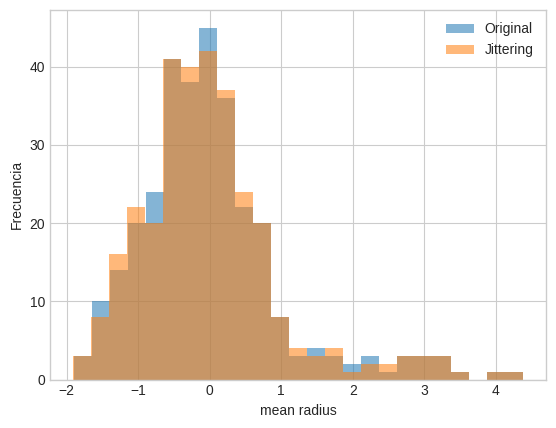

In [5]:
# Trabajamos en escala estandarizada para que el ruido tenga magnitud comparable.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

noise = rng.normal(0, 0.03, size=X_scaled.shape)
X_jitter = X_scaled + noise

alpha = rng.normal(1.0, 0.03, size=(len(X_scaled), 1))
X_scaled_aug = X_scaled * alpha

feature = 0
plt.hist(X_scaled[:, feature], bins=25, alpha=.55, label="Original")
plt.hist(X_jitter[:, feature], bins=25, alpha=.55, label="Jittering")
plt.xlabel(data.feature_names[feature]); plt.ylabel("Frecuencia"); plt.legend();

### 2.4 SMOTE paso a paso

SMOTE no duplica una observación. Para generar cada muestra sintética:

1. Selecciona una observación $x_i$ de la clase minoritaria.
2. Encuentra sus $k$ vecinos más cercanos **de la misma clase**.
3. Elige aleatoriamente uno de ellos, $x_j$.
4. Genera $\lambda\sim U(0,1)$.
5. Interpola sobre el segmento que une ambas observaciones:

$$x_{nuevo}=x_i+\lambda(x_j-x_i), \qquad 0\leq\lambda\leq1.$$

Si $\lambda=0$, la muestra coincide con $x_i$; si $\lambda=1$, coincide con $x_j$. Los valores intermedios crean una observación nueva entre ambas. Estandarizamos primero porque los vecinos dependen de las distancias y las variables originales tienen escalas distintas.

In [6]:
from sklearn.neighbors import NearestNeighbors

# 1. Identificar la clase con menos observaciones.
minority_label = y_train.value_counts().idxmin()
minority_mask = y_train.to_numpy() == minority_label

# 2. Ajustar el escalador SOLO con entrenamiento y transformar sus datos.
X_train_scaled = scaler.fit_transform(X_train)
X_min = X_train_scaled[minority_mask]

# 3. Buscar k vecinos dentro de la clase minoritaria.
k = min(5, len(X_min) - 1)
# Se solicitan k+1 porque el vecino más cercano de cada punto es él mismo.
nn = NearestNeighbors(n_neighbors=k + 1)
nn.fit(X_min)

# 4. Elegir una muestra base y obtener sus vecinos, excluyéndose a sí misma.
i = 0
distances, indices = nn.kneighbors(X_min[[i]])
neighbor_indices = indices[0, 1:]
neighbor_distances = distances[0, 1:]

neighbors_table = pd.DataFrame({
    "índice del vecino": neighbor_indices,
    "distancia": neighbor_distances
})
neighbors_table

,índice del vecino,distancia
0,35,5.351882
1,16,6.254078
2,1,6.599397
3,14,6.644840
4,29,6.685702


In [7]:
# 5. Elegir un vecino y un valor de interpolación.
j = int(rng.choice(neighbor_indices))
lam = rng.uniform(0, 1)

x_i = X_min[i]
x_j = X_min[j]
x_new = x_i + lam * (x_j - x_i)

comparison = pd.DataFrame(
    [x_i[:5], x_j[:5], x_new[:5]],
    index=["Muestra base xi", "Vecino xj", "Sintética x_new"],
    columns=X_train.columns[:5]
)

print(f"Clase minoritaria: {minority_label}")
print(f"Muestra base i={i}; vecino elegido j={j}; lambda={lam:.3f}")
comparison.round(3)

Clase minoritaria: 0
Muestra base i=0; vecino elegido j=14; lambda=0.519


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
Muestra base xi,2.499,1.186,2.496,2.580,0.519
Vecino xj,2.295,0.119,2.198,2.436,-0.858
Sintética x_new,2.393,0.633,2.341,2.505,-0.195


#### Visualización de una interpolación

La interpolación ocurre simultáneamente en todas las variables. Para visualizarla mostramos únicamente las dos primeras: el punto sintético debe quedar sobre el segmento entre la muestra base y el vecino seleccionado.

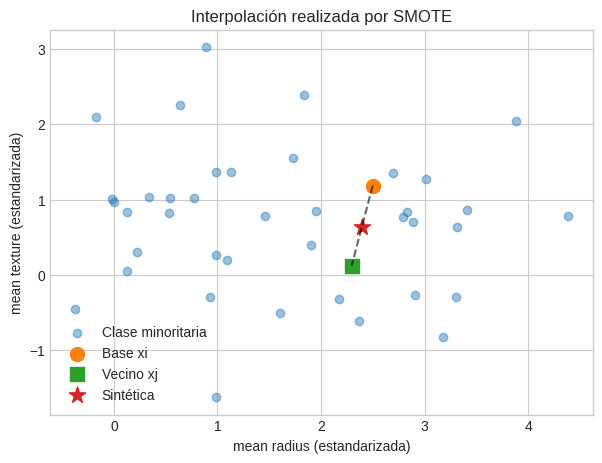

In [8]:
f1, f2 = 0, 1
plt.figure(figsize=(7, 5))
plt.scatter(X_min[:, f1], X_min[:, f2], alpha=.45, label="Clase minoritaria")
plt.plot([x_i[f1], x_j[f1]], [x_i[f2], x_j[f2]], "k--", alpha=.6)
plt.scatter(x_i[f1], x_i[f2], s=100, marker="o", label="Base xi")
plt.scatter(x_j[f1], x_j[f2], s=100, marker="s", label="Vecino xj")
plt.scatter(x_new[f1], x_new[f2], s=150, marker="*", label="Sintética")
plt.xlabel(X_train.columns[f1] + " (estandarizada)")
plt.ylabel(X_train.columns[f2] + " (estandarizada)")
plt.title("Interpolación realizada por SMOTE")
plt.legend();

#### Generar suficientes muestras para balancear las clases

La siguiente función repite el procedimiento. Cada ejemplo sintético parte de una muestra minoritaria elegida al azar y uno de sus $k$ vecinos. Es una implementación educativa: para proyectos reales conviene usar `imblearn.over_sampling.SMOTE`, que ofrece validaciones y variantes adicionales.

In [9]:
def manual_smote(X_minority, n_samples, k=5, random_state=42):
    # Genera muestras sintéticas SMOTE a partir de datos numéricos escalados.
    local_rng = np.random.default_rng(random_state)
    k = min(k, len(X_minority) - 1)
    if k < 1:
        raise ValueError("Se necesitan al menos dos muestras minoritarias.")

    model = NearestNeighbors(n_neighbors=k + 1).fit(X_minority)
    all_neighbors = model.kneighbors(X_minority, return_distance=False)[:, 1:]
    synthetic = []

    for _ in range(n_samples):
        i = int(local_rng.integers(len(X_minority)))
        j = int(local_rng.choice(all_neighbors[i]))
        lam = local_rng.uniform(0, 1)
        synthetic.append(X_minority[i] + lam * (X_minority[j] - X_minority[i]))

    return np.asarray(synthetic)

# Número necesario para igualar la clase mayoritaria.
class_counts = y_train.value_counts()
n_to_generate = int(class_counts.max() - class_counts.min())
X_synthetic = manual_smote(X_min, n_samples=n_to_generate, k=5)

# Conjunto balanceado en escala estandarizada.
X_smote_scaled = np.vstack([X_train_scaled, X_synthetic])
y_smote = np.r_[y_train.to_numpy(), np.full(n_to_generate, minority_label)]

print("Muestras sintéticas generadas:", len(X_synthetic))
print("Distribución después de SMOTE:", pd.Series(y_smote).value_counts().sort_index().to_dict())

Muestras sintéticas generadas: 227
Distribución después de SMOTE: {0: 268, 1: 268}


## 4. Series de tiempo

En series deben conservarse la dinámica y la etiqueta. Aplicaremos:

- **jittering:** ruido pequeño;
- **scaling:** cambio global de amplitud;
- **magnitude warping:** factor suave que cambia con el tiempo;
- **window slicing:** recorte y reinterpolación al tamaño original.

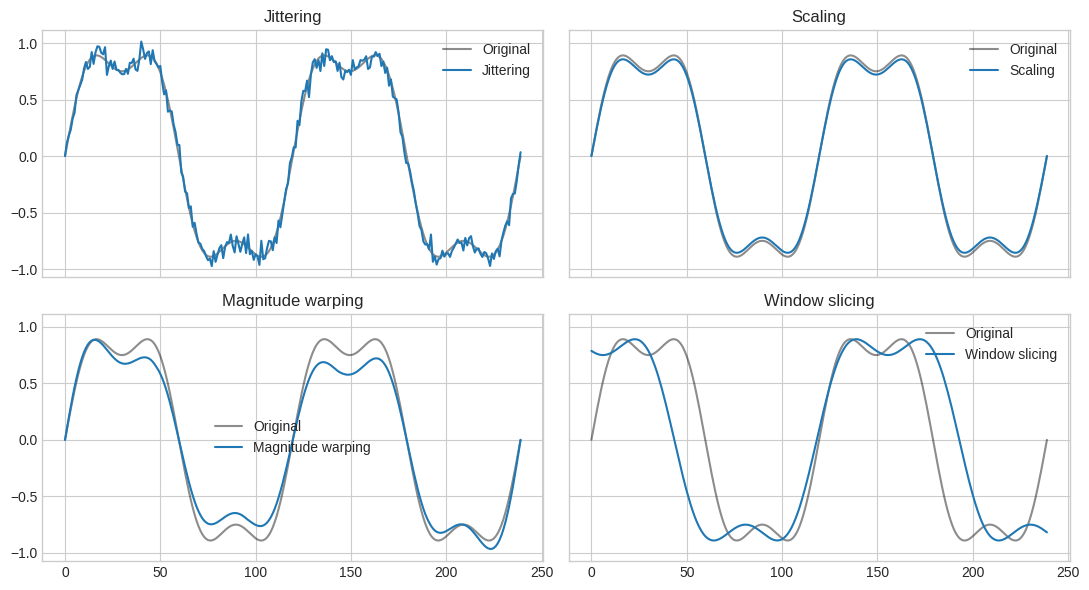

In [10]:
t = np.linspace(0, 4*np.pi, 240)
signal = np.sin(t) + 0.25*np.sin(3*t)

jitter = signal + rng.normal(0, 0.05, len(signal))
scaling = signal * rng.normal(1.0, 0.08)

# Curva suave de magnitud mediante interpolación de pocos puntos de control.
knots_x = np.linspace(0, len(signal)-1, 6)
knots_y = rng.normal(1.0, 0.12, len(knots_x))
warp_curve = np.interp(np.arange(len(signal)), knots_x, knots_y)
magnitude_warp = signal * warp_curve

# Recortamos 80% y reinterpolamos al largo original.
start, width = 25, int(0.8 * len(signal))
window = signal[start:start+width]
window_slice = np.interp(
    np.linspace(0, len(window)-1, len(signal)), np.arange(len(window)), window
)

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)
for ax, augmented, title in zip(
    axes.ravel(), [jitter, scaling, magnitude_warp, window_slice],
    ["Jittering", "Scaling", "Magnitude warping", "Window slicing"]
):
    ax.plot(signal, color="black", alpha=.45, label="Original")
    ax.plot(augmented, label=title)
    ax.set_title(title); ax.legend()
plt.tight_layout()

## 5. Imágenes

Usaremos una imagen de ejemplo incluida en `scikit-learn`. Las transformaciones son adecuadas solo si no cambian la clase. Por ejemplo, un *flip* horizontal suele ser razonable para un animal, pero no necesariamente para texto o señales de tránsito.

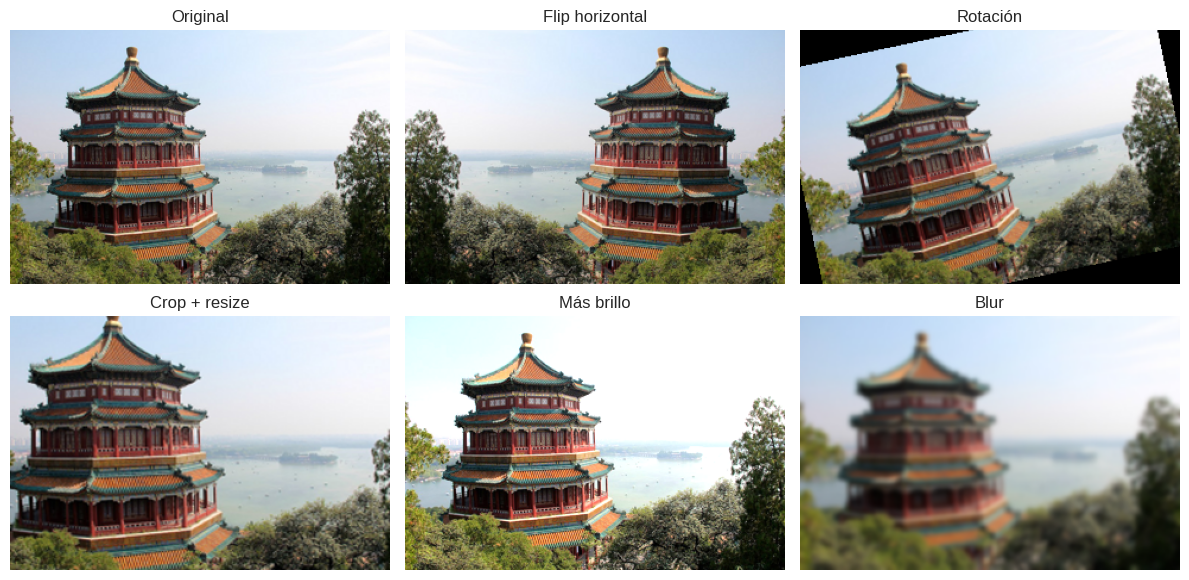

In [11]:
img = Image.fromarray(load_sample_image("china.jpg"))
img_small = img.resize((320, 214))

augmented_images = [
    ("Original", img_small),
    ("Flip horizontal", img_small.transpose(Image.Transpose.FLIP_LEFT_RIGHT)),
    ("Rotación", img_small.rotate(12, resample=Image.Resampling.BILINEAR)),
    ("Crop + resize", img_small.crop((35, 20, 285, 194)).resize(img_small.size)),
    ("Más brillo", ImageEnhance.Brightness(img_small).enhance(1.25)),
    ("Blur", img_small.filter(ImageFilter.GaussianBlur(radius=2))),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (title, im) in zip(axes.ravel(), augmented_images):
    ax.imshow(im); ax.set_title(title); ax.axis("off")
plt.tight_layout()

### 4.1 MixUp y CutMix

- **MixUp:** combinación lineal de dos imágenes y de sus etiquetas.
- **CutMix:** sustituye una región por un parche de otra imagen; la etiqueta se pondera según el área mezclada.

Aquí se muestran solo las imágenes. En entrenamiento también deben mezclarse correctamente sus etiquetas.

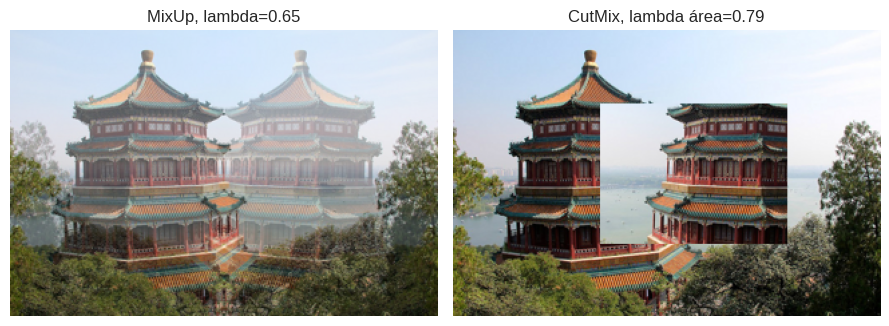

In [12]:
img_a = np.asarray(img_small).astype(float) / 255
img_b = np.asarray(img_small.transpose(Image.Transpose.FLIP_LEFT_RIGHT)).astype(float) / 255

lam = 0.65
mixup = lam * img_a + (1-lam) * img_b

cutmix = img_a.copy()
y1, y2, x1, x2 = 55, 160, 110, 250
cutmix[y1:y2, x1:x2] = img_b[y1:y2, x1:x2]
lam_area = 1 - ((y2-y1)*(x2-x1))/(img_a.shape[0]*img_a.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mixup); axes[0].set_title(f"MixUp, lambda={lam}")
axes[1].imshow(cutmix); axes[1].set_title(f"CutMix, lambda área={lam_area:.2f}")
for ax in axes: ax.axis("off")
plt.tight_layout()

## 6. Texto: Easy Data Augmentation (EDA)

En texto hay que ser más cuidadoso: cambiar una palabra puede alterar el significado o la etiqueta. Implementaremos versiones sencillas de reemplazo, inserción, intercambio y eliminación. El pequeño diccionario es deliberadamente controlado.

In [13]:
sentence = "el modelo aprende patrones útiles con datos diversos"
synonyms = {"modelo": "sistema", "aprende": "identifica", "útiles": "relevantes", "diversos": "variados"}

def synonym_replacement(text):
    words = text.split()
    candidates = [i for i, w in enumerate(words) if w in synonyms]
    if candidates:
        i = rng.choice(candidates); words[i] = synonyms[words[i]]
    return " ".join(words)

def random_insertion(text):
    words = text.split(); words.insert(int(rng.integers(len(words)+1)), "realmente")
    return " ".join(words)

def random_swap(text):
    words = text.split(); i, j = rng.choice(len(words), 2, replace=False)
    words[i], words[j] = words[j], words[i]
    return " ".join(words)

def random_deletion(text, p=0.15):
    kept = [w for w in text.split() if rng.random() > p]
    return " ".join(kept) or text

pd.DataFrame({
    "Técnica": ["Original", "Sinónimo", "Inserción", "Intercambio", "Eliminación"],
    "Texto": [sentence, synonym_replacement(sentence), random_insertion(sentence),
              random_swap(sentence), random_deletion(sentence)]
})

,Técnica,Texto
0,Original,el modelo aprende patrones útiles con datos di...
1,Sinónimo,el modelo identifica patrones útiles con datos...
2,Inserción,el modelo aprende patrones útiles con datos re...
3,Intercambio,patrones modelo aprende el útiles con datos di...
4,Eliminación,el modelo aprende patrones con


## 7. Evaluación breve: estudio de ablación

El aumento no garantiza una mejora. Debe compararse con una línea base usando **el mismo conjunto de prueba sin aumentar**. Como ejemplo corto, comparamos regresión logística sin balanceo y con oversampling. Usamos *balanced accuracy* porque las clases están desbalanceadas.

In [14]:
def evaluate(Xtr, ytr):
    scale = StandardScaler()
    Xtr_s = scale.fit_transform(Xtr)
    Xte_s = scale.transform(X_test)
    model = LogisticRegression(max_iter=2000, random_state=42)
    model.fit(Xtr_s, ytr)
    return balanced_accuracy_score(y_test, model.predict(Xte_s))

results = pd.DataFrame({
    "Configuración": ["Sin aumento", "Random oversampling"],
    "Balanced accuracy": [evaluate(X_train, y_train), evaluate(X_over, y_over)]
})
results.round(3)

,Configuración,Balanced accuracy
0,Sin aumento,1.000
1,Random oversampling,0.994


## 8. Buenas prácticas y conclusiones

1. Dividir entrenamiento, validación y prueba **antes** de aumentar.
2. Aplicar aumento solamente al entrenamiento.
3. Elegir transformaciones que conserven la etiqueta y sean plausibles en el dominio.
4. Ajustar la intensidad: transformaciones excesivas pueden crear ejemplos irreales.
5. Comparar contra una línea base y realizar ablaciones.
6. Inspeccionar ejemplos sintéticos, distribuciones y posibles sesgos.

No existe una técnica que sea siempre mejor: la elección depende del tipo de datos, el problema y el conocimiento del dominio.

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de ChatGPT 5.6 (OpenAI) para estructurar el contenido a partir de las diapositivas de la sesión y redactar el texto explicativo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.